# NFL Formation Analysis
## Case Study: Seattle Seahawks vs Los Angeles Rams (2025)

This notebook applies the formation matchup framework built across notebooks 03-07 to a specific real-world rivalry — the Seattle Seahawks vs Los Angeles Rams across their 3 games in the 2025 season, including a playoff matchup. We examine how each team's formation and personnel tendencies matched up against the other's defensive schemes, identify where each team found success, and highlight where they left value on the table based on the league-wide matchup data.

---

### Setup & Data Load

In [1]:
%pip install matplotlib seaborn pandas==2.2.2 --prefer-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

all_plays = pd.read_parquet(os.path.join(processed_path, "all_plays.parquet"))

# Filter to SEA vs LA 2025
sea_la = all_plays[
    (all_plays['season'] == 2025) &
    (
        ((all_plays['home_team'] == 'SEA') & (all_plays['away_team'] == 'LA')) |
        ((all_plays['home_team'] == 'LA') & (all_plays['away_team'] == 'SEA'))
    )
].copy()

print(f"Total SEA vs LA plays: {len(sea_la):,}")
print(f"\nGames:")
for game in sea_la['game_id'].unique():
    game_plays = sea_la[sea_la['game_id'] == game]
    print(f"  {game}: {len(game_plays)} plays")

print(f"\nSEA offense plays: {len(sea_la[sea_la['posteam'] == 'SEA']):,}")
print(f"LA offense plays: {len(sea_la[sea_la['posteam'] == 'LA']):,}")

Total SEA vs LA plays: 404

Games:
  2025_11_SEA_LA: 129 plays
  2025_16_LA_SEA: 153 plays
  2025_21_LA_SEA: 122 plays

SEA offense plays: 209
LA offense plays: 195


404 pass and run plays across 3 games — 2 regular season matchups and 1 playoff game (week 21). The series is nearly evenly split between Seattle and LA offensive possessions, giving us a balanced sample for analyzing both sides.

---

### Formation Usage Comparison
How did each team's formation tendencies differ across the series?

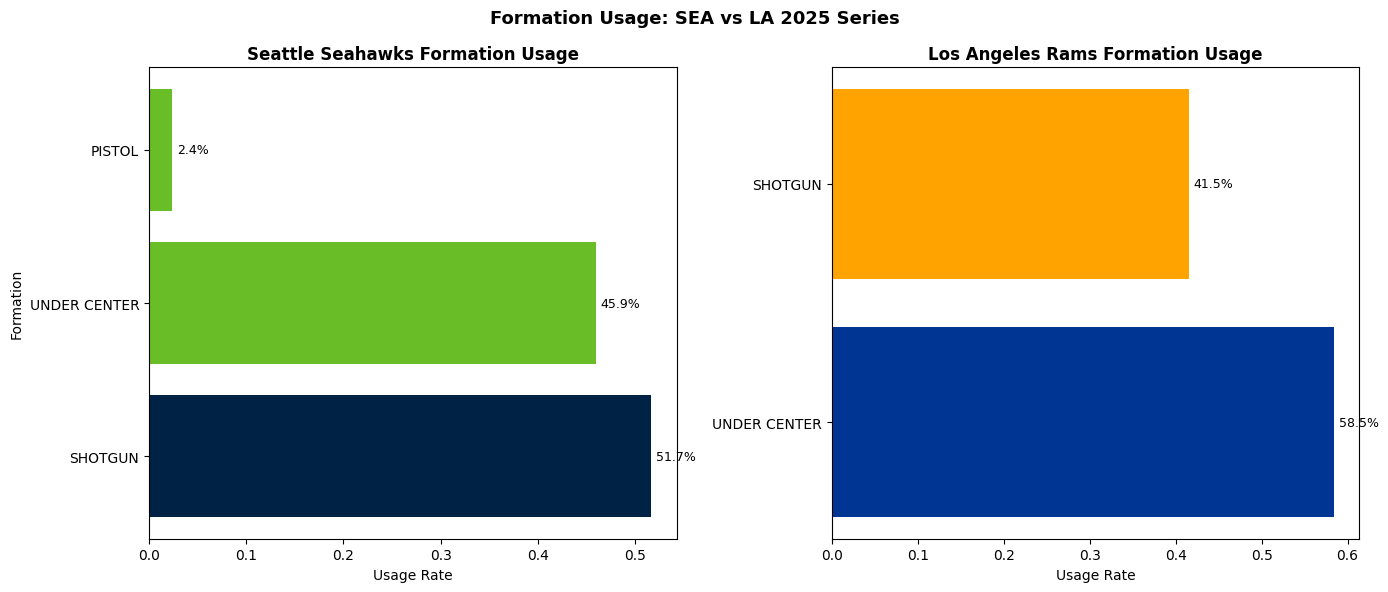

SEA Formation Usage:
offense_formation
SHOTGUN         0.516746
UNDER CENTER    0.459330
PISTOL          0.023923

LA Formation Usage:
offense_formation
UNDER CENTER    0.584615
SHOTGUN         0.415385


In [3]:
# Formation usage by team
sea_offense = sea_la[sea_la['posteam'] == 'SEA'].copy()
la_offense = sea_la[sea_la['posteam'] == 'LA'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# SEA formation usage
sea_formation = sea_offense['offense_formation'].value_counts()
sea_formation_pct = sea_formation / sea_formation.sum()
colors_sea = ['#002244' if i == 0 else '#69BE28' for i in range(len(sea_formation_pct))]
axes[0].barh(sea_formation_pct.index, sea_formation_pct.values, color=colors_sea)
axes[0].set_title('Seattle Seahawks Formation Usage', fontweight='bold')
axes[0].set_xlabel('Usage Rate')
axes[0].set_ylabel('Formation')
for i, (idx, val) in enumerate(sea_formation_pct.items()):
    axes[0].text(val + 0.005, i, f'{val:.1%}', va='center', fontsize=9)

# LA formation usage
la_formation = la_offense['offense_formation'].value_counts()
la_formation_pct = la_formation / la_formation.sum()
colors_la = ['#003594' if i == 0 else '#FFA300' for i in range(len(la_formation_pct))]
axes[1].barh(la_formation_pct.index, la_formation_pct.values, color=colors_la)
axes[1].set_title('Los Angeles Rams Formation Usage', fontweight='bold')
axes[1].set_xlabel('Usage Rate')
axes[1].set_ylabel('')
for i, (idx, val) in enumerate(la_formation_pct.items()):
    axes[1].text(val + 0.005, i, f'{val:.1%}', va='center', fontsize=9)

plt.suptitle('Formation Usage: SEA vs LA 2025 Series', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "sea_la_formation_usage.png"), dpi=150, bbox_inches='tight')
plt.show()

print("SEA Formation Usage:")
print(sea_formation_pct.to_string())
print("\nLA Formation Usage:")
print(la_formation_pct.to_string())

![SEA vs LA Formation Usage](../outputs/figures/sea_la_formation_usage.png)

The formation usage comparison immediately reveals two very different offensive philosophies:

**Seattle Seahawks:**
- **Shotgun (52%) and Under Center (46%)** — nearly equal split, one of the most balanced formation profiles in the league
- Only 2.4% Pistol — essentially a two-formation offense
- Seattle's heavy Under Center usage reflects their run-first identity under their offensive scheme

**Los Angeles Rams:**
- **Under Center dominates at 58.5%** — the Rams are one of the most traditional formation teams in the modern NFL
- Shotgun at only 41.5% — well below the league average of 56%
- Zero Pistol or other formations — a pure two-formation offense

**The contrast is striking.** Both teams are running significantly more Under Center than the league average, which based on our earlier analysis (+0.104 EPA on pass plays) should give both offenses an advantage over spread-heavy opponents. The Rams lean even harder into traditional formations than the Seahawks.

---

### EPA Performance by Formation
How did each team's formations actually perform in this series?

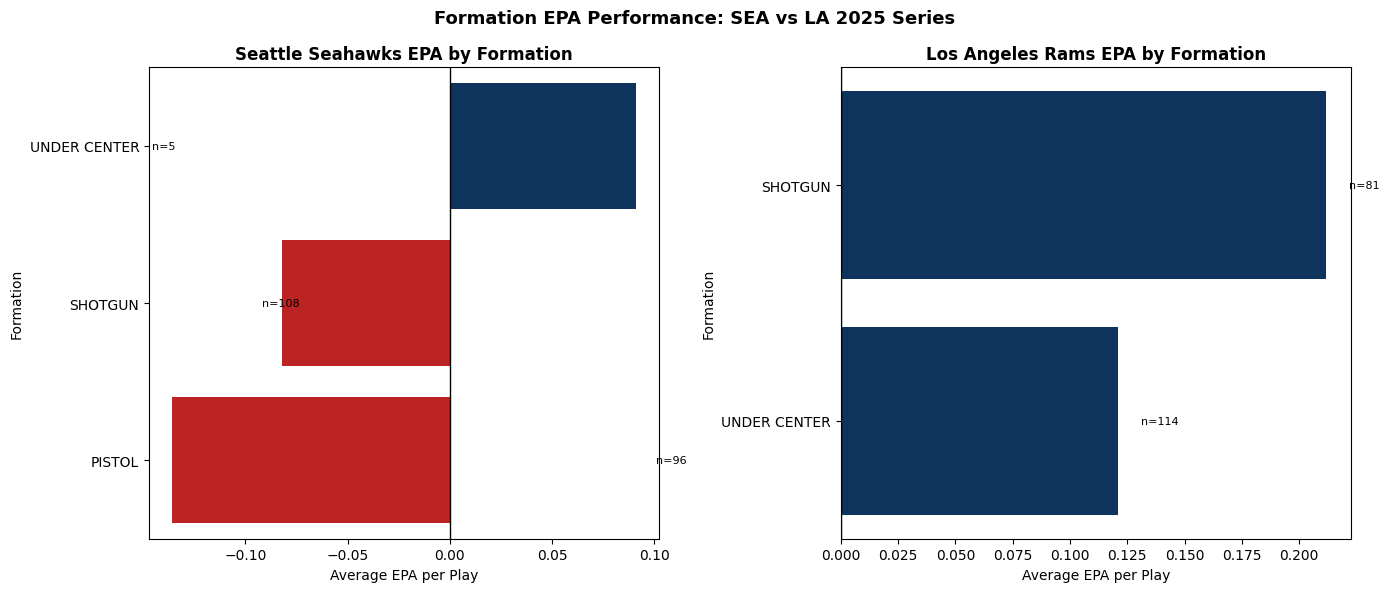

SEA Formation EPA:
                   plays   avg_epa
offense_formation                 
UNDER CENTER          96  0.090896
SHOTGUN              108 -0.082133
PISTOL                 5 -0.135839

LA Formation EPA:
                   plays   avg_epa
offense_formation                 
SHOTGUN               81  0.211847
UNDER CENTER         114  0.120786


In [4]:
# EPA by formation for each team
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, team, team_data, title, primary_color in [
    (axes[0], 'SEA', sea_offense, 'Seattle Seahawks EPA by Formation', '#002244'),
    (axes[1], 'LA', la_offense, 'Los Angeles Rams EPA by Formation', '#003594')
]:
    formation_epa = team_data.groupby('offense_formation').agg(
        plays=('epa', 'count'),
        avg_epa=('epa', 'mean')
    ).reset_index()
    formation_epa = formation_epa[formation_epa['plays'] >= 5].sort_values('avg_epa', ascending=False)

    colors = ['#013369' if x > 0 else '#D50A0A' for x in formation_epa['avg_epa']]
    sns.barplot(data=formation_epa, x='avg_epa', y='offense_formation',
                hue='offense_formation',
                palette=dict(zip(formation_epa['offense_formation'], colors)),
                legend=False, ax=ax)
    ax.axvline(x=0, color='black', linewidth=1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Average EPA per Play')
    ax.set_ylabel('Formation')

    for _, row in formation_epa.iterrows():
        ax.text(row['avg_epa'] + 0.01 if row['avg_epa'] >= 0 else row['avg_epa'] - 0.01,
                formation_epa[formation_epa['offense_formation'] == row['offense_formation']].index[0],
                f"n={int(row['plays'])}", va='center', fontsize=8)

plt.suptitle('Formation EPA Performance: SEA vs LA 2025 Series', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "sea_la_formation_epa.png"), dpi=150, bbox_inches='tight')
plt.show()

print("SEA Formation EPA:")
print(sea_offense.groupby('offense_formation').agg(
    plays=('epa', 'count'), avg_epa=('epa', 'mean')).sort_values('avg_epa', ascending=False).to_string())
print("\nLA Formation EPA:")
print(la_offense.groupby('offense_formation').agg(
    plays=('epa', 'count'), avg_epa=('epa', 'mean')).sort_values('avg_epa', ascending=False).to_string())

![SEA vs LA Formation EPA](../outputs/figures/sea_la_formation_epa.png)

The formation EPA chart tells a clear and compelling story about how each team performed in this series:

**Seattle Seahawks:**
- **Under Center (+0.090 EPA, 96 plays)** — Seattle's traditional formation was their most effective, consistent with the league-wide finding that Under Center generates positive pass EPA
- **Shotgun (-0.082 EPA, 108 plays)** — Seattle's most used formation was also their worst performing one, dragging down their overall offensive efficiency
- **Pistol (-0.136 EPA, 5 plays)** — small sample but negative

Seattle's formation problem is clear: they used Shotgun more than Under Center despite Shotgun generating negative EPA against the Rams defense. Shifting even 20% of Shotgun plays to Under Center would have meaningfully improved their offensive output.

**Los Angeles Rams:**
- **Shotgun (+0.212 EPA, 81 plays)** — the Rams were exceptional out of Shotgun against Seattle's defense
- **Under Center (+0.121 EPA, 114 plays)** — also strongly positive, their dominant formation

The Rams generated positive EPA out of both formations — a sign of a well-executing offense that found success regardless of alignment. Their Shotgun EPA of +0.212 is dramatically higher than the league average of +0.006, suggesting they used Shotgun in optimal situations against Seattle's defense.

---

### Personnel Package Comparison
How did each team's personnel usage and performance compare?

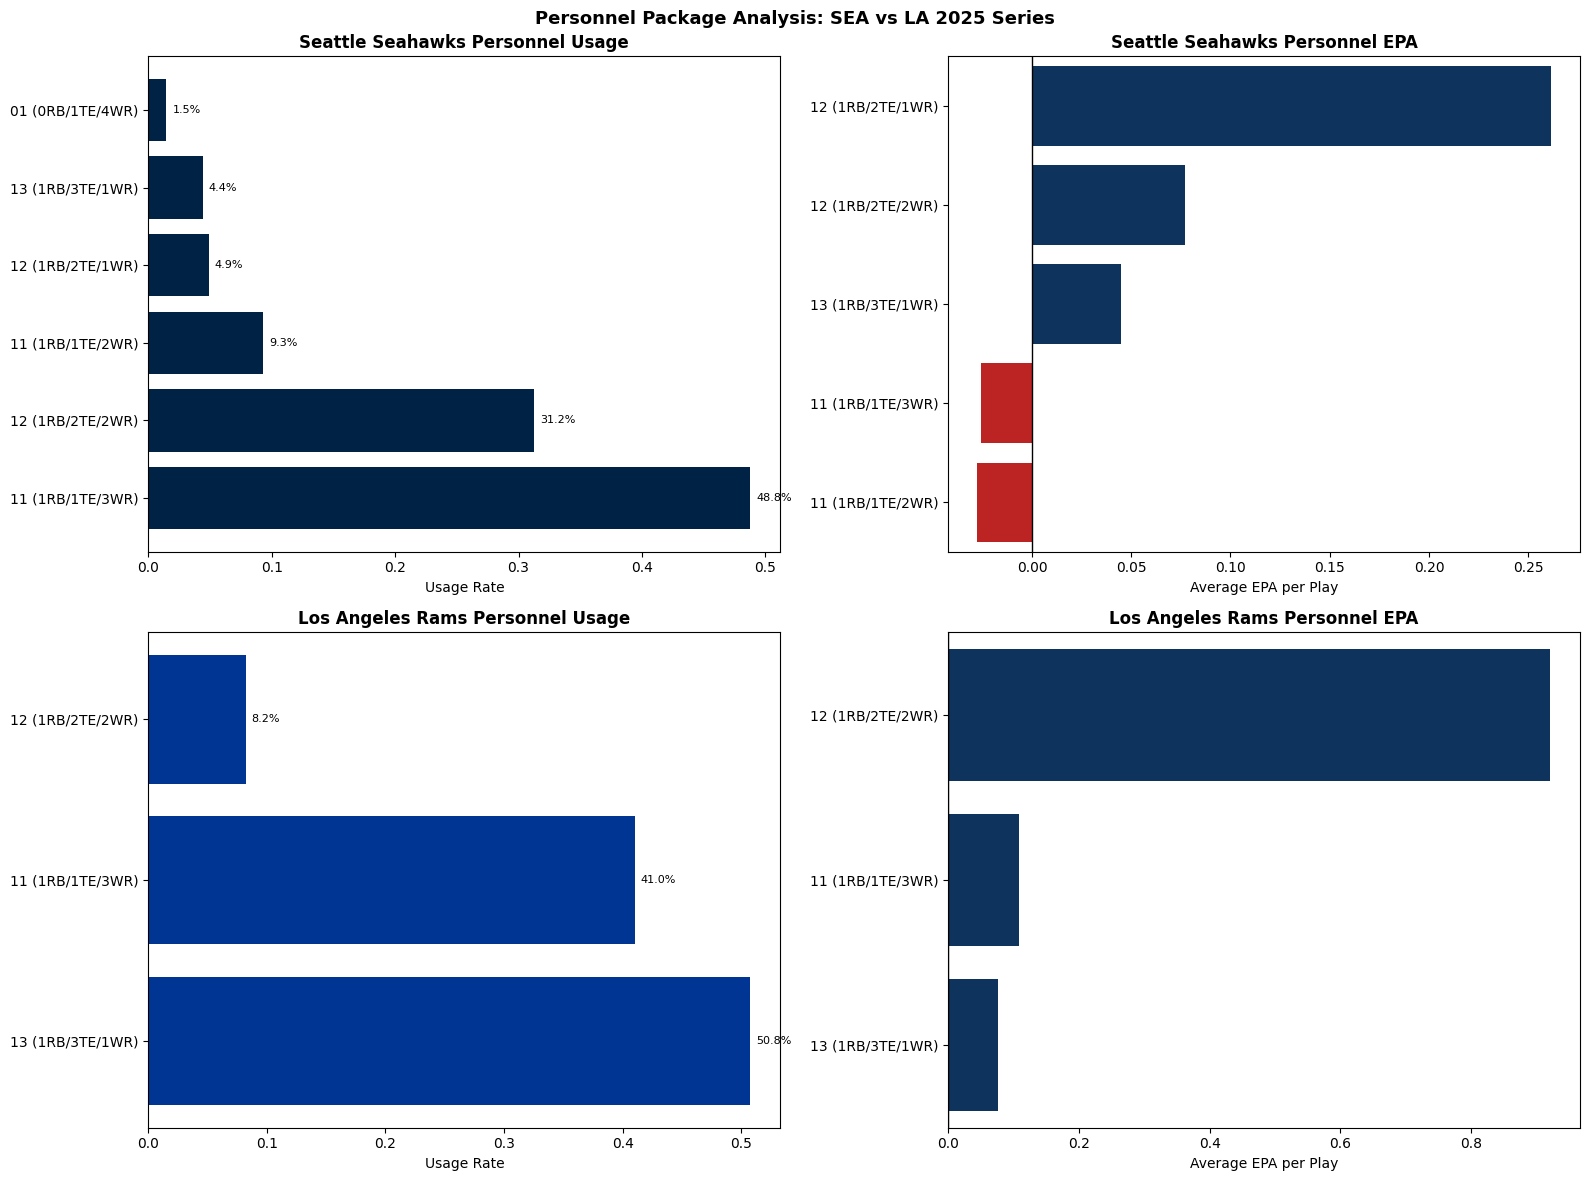

SEA Personnel:
                   plays   avg_epa
personnel_package                 
11 (1RB/1TE/3WR)     100 -0.025861
12 (1RB/2TE/2WR)      64  0.076863
11 (1RB/1TE/2WR)      19 -0.027825
12 (1RB/2TE/1WR)      10  0.261582
13 (1RB/3TE/1WR)       9  0.044978
01 (0RB/1TE/4WR)       3 -1.203089

LA Personnel:
                   plays   avg_epa
personnel_package                 
13 (1RB/3TE/1WR)      99  0.075859
11 (1RB/1TE/3WR)      80  0.108660
12 (1RB/2TE/2WR)      16  0.920394


In [6]:
# Personnel usage and EPA comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row, (team, team_data, name) in enumerate([
    ('SEA', sea_offense, 'Seattle Seahawks'),
    ('LA', la_offense, 'Los Angeles Rams')
]):
    personnel_usage = team_data['personnel_package'].value_counts().head(6)
    personnel_usage_pct = personnel_usage / personnel_usage.sum()

    personnel_epa = team_data.groupby('personnel_package').agg(
        plays=('epa', 'count'),
        avg_epa=('epa', 'mean')
    ).reset_index()
    personnel_epa = personnel_epa[personnel_epa['plays'] >= 5].sort_values('avg_epa', ascending=False)

    # Usage
    primary = '#002244' if team == 'SEA' else '#003594'
    axes[row][0].barh(personnel_usage_pct.index, personnel_usage_pct.values, color=primary)
    axes[row][0].set_title(f'{name} Personnel Usage', fontweight='bold')
    axes[row][0].set_xlabel('Usage Rate')
    for i, (idx, val) in enumerate(personnel_usage_pct.items()):
        axes[row][0].text(val + 0.005, i, f'{val:.1%}', va='center', fontsize=8)

    # EPA
    colors = ['#013369' if x > 0 else '#D50A0A' for x in personnel_epa['avg_epa']]
    sns.barplot(data=personnel_epa, x='avg_epa', y='personnel_package',
                hue='personnel_package',
                palette=dict(zip(personnel_epa['personnel_package'], colors)),
                legend=False, ax=axes[row][1])
    axes[row][1].axvline(x=0, color='black', linewidth=1)
    axes[row][1].set_title(f'{name} Personnel EPA', fontweight='bold')
    axes[row][1].set_xlabel('Average EPA per Play')
    axes[row][1].set_ylabel('')

plt.suptitle('Personnel Package Analysis: SEA vs LA 2025 Series', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "sea_la_personnel.png"), dpi=150, bbox_inches='tight')
plt.show()

print("SEA Personnel:")
print(sea_offense.groupby('personnel_package').agg(
    plays=('epa', 'count'), avg_epa=('epa', 'mean')).sort_values('plays', ascending=False).head(6).to_string())
print("\nLA Personnel:")
print(la_offense.groupby('personnel_package').agg(
    plays=('epa', 'count'), avg_epa=('epa', 'mean')).sort_values('plays', ascending=False).head(6).to_string())

![SEA vs LA Personnel Analysis](../outputs/figures/sea_la_personnel.png)

The personnel data reveals dramatically different philosophies and results between the two teams:

**Seattle Seahawks personnel:**
- **11 personnel (48.8%)** — standard 3-wide set is their base package
- **12 personnel (31.2%)** — two tight end sets are heavily used, reflecting their run-first identity
- Their best performing package is **12 personnel with 1 WR (+0.262 EPA)** — a heavy set that generated outsized value in limited usage
- **12 personnel with 2 WR (+0.077 EPA)** — also positive and heavily used
- **11 personnel goes negative (-0.026 EPA)** — their most used package is their worst performing one against the Rams

**Los Angeles Rams personnel:**
- **13 personnel (50.8%)** — three tight end sets are their base package, one of the most unusual personnel profiles in the NFL
- **11 personnel (41.0%)** — standard 3-wide as their secondary package
- **12 personnel with 2 WR generated +0.920 EPA** — an extraordinary number, the best single personnel package performance in this series
- All three packages generated positive EPA — the Rams executed well across every personnel grouping

**The most important finding:** The Rams' heavy use of 13 personnel (3 TEs) is directly aligned with our league-wide finding that 13 personnel is the most blitz-proof package and generates strong EPA against man coverage. Against Seattle's defense this strategy worked extremely well.

Seattle's reliance on 11 personnel despite negative EPA in this series suggests they were unable to adjust their personnel usage to exploit weaknesses in the Rams defense.

---

### Route Performance vs Coverage
Which routes did each team run most effectively against the other's coverage?

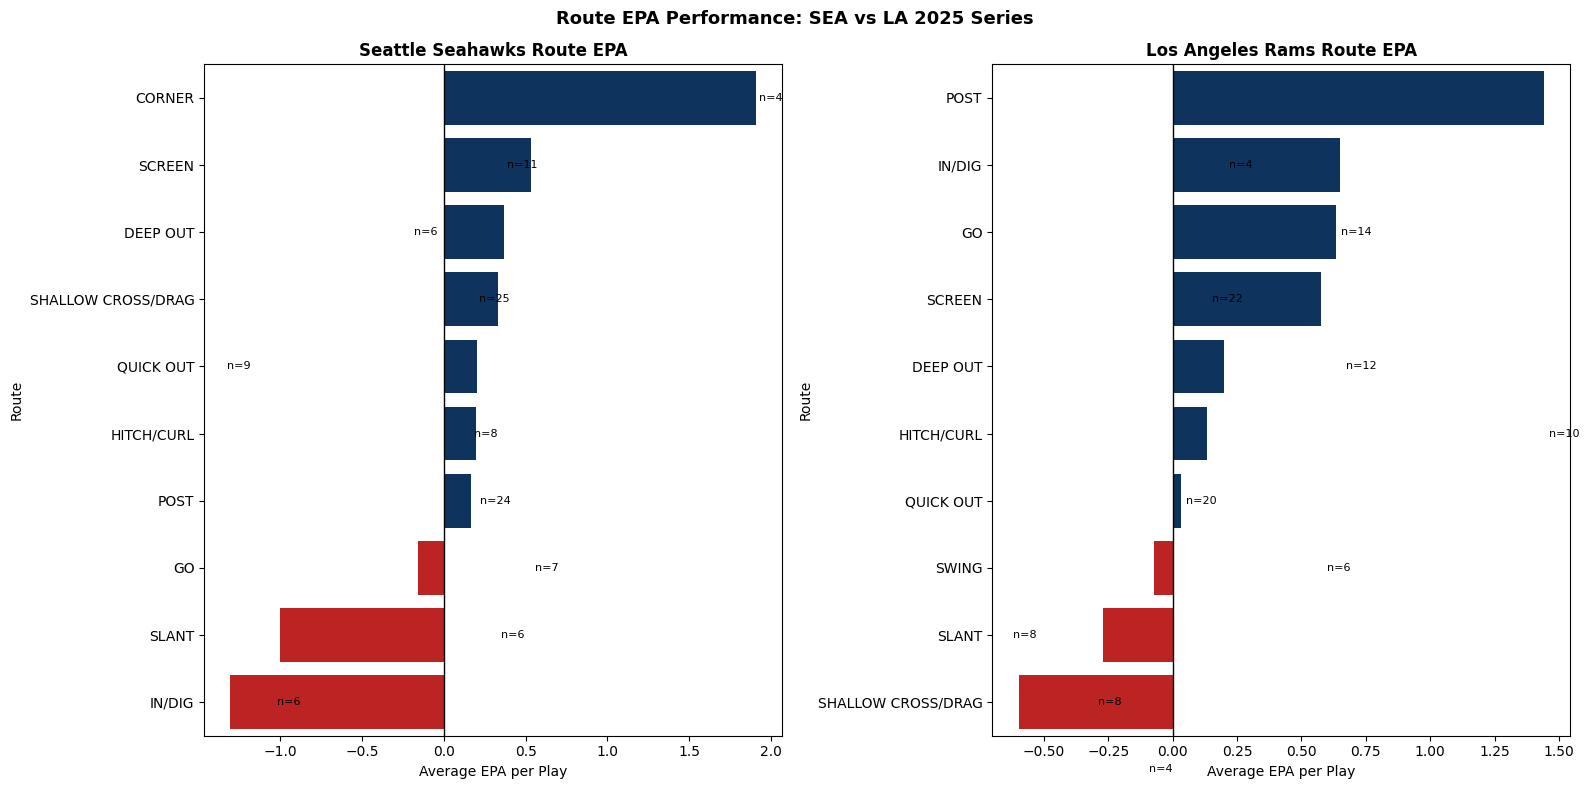

In [7]:
# Route performance for each team
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, team, team_data, name, color in [
    (axes[0], 'SEA', sea_offense, 'Seattle Seahawks', '#002244'),
    (axes[1], 'LA', la_offense, 'Los Angeles Rams', '#003594')
]:
    route_epa = team_data.dropna(subset=['route']).copy()
    route_epa = route_epa[route_epa['route'] != '']
    route_epa = route_epa.groupby('route').agg(
        plays=('epa', 'count'),
        avg_epa=('epa', 'mean')
    ).reset_index()
    route_epa = route_epa[route_epa['plays'] >= 3].sort_values('avg_epa', ascending=False)

    colors = ['#013369' if x > 0 else '#D50A0A' for x in route_epa['avg_epa']]
    sns.barplot(data=route_epa, x='avg_epa', y='route',
                hue='route',
                palette=dict(zip(route_epa['route'], colors)),
                legend=False, ax=ax)
    ax.axvline(x=0, color='black', linewidth=1)
    ax.set_title(f'{name} Route EPA', fontweight='bold')
    ax.set_xlabel('Average EPA per Play')
    ax.set_ylabel('Route')
    for _, row in route_epa.iterrows():
        x_pos = row['avg_epa'] + 0.02 if row['avg_epa'] >= 0 else row['avg_epa'] - 0.02
        ax.text(x_pos, route_epa[route_epa['route'] == row['route']].index[0],
                f"n={int(row['plays'])}", va='center', fontsize=8)

plt.suptitle('Route EPA Performance: SEA vs LA 2025 Series', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "sea_la_routes.png"), dpi=150, bbox_inches='tight')
plt.show()

![SEA vs LA Route EPA](../outputs/figures/sea_la_routes.png)

The route performance chart reveals which concepts each team's defense was vulnerable to and which routes each offense leaned on most successfully:

**Seattle Seahawks route performance:**
- **Corner route (+1.93 EPA, n=4)** — Seattle's most explosive route in the series, though small sample
- **Shallow Cross/Drag (+0.28 EPA, n=25)** — their highest volume successful route, 25 plays with consistent positive EPA
- **Screen (+0.35 EPA, n=11)** — screens worked against the Rams defense, contrasting with the league-wide finding that screens underperform
- **Post route (+0.05 EPA, n=24)** — positive but below the league-wide average for post routes, suggesting the Rams defended it well
- **In/Dig (-1.08 EPA, n=6)** — Seattle's worst route by far, the Rams completely shut down crossing routes over the middle
- **Slant (-0.69 EPA, n=6)** — also badly defended by the Rams

**Los Angeles Rams route performance:**
- **Post route (+1.43 EPA, n=4)** — consistent with the league-wide finding that posts are universally dominant
- **Go route (+0.61 EPA, n=14)** — verticals worked well against Seattle's coverage
- **In/Dig (+0.63 EPA, n=4)** — the exact opposite of Seattle's experience, the Rams succeeded on crossing routes where Seattle failed
- **Screen (+0.55 EPA, n=22)** — screens were highly effective for the Rams, a significant volume route
- **Shallow Cross/Drag (-0.55 EPA, n=8)** — Seattle successfully defended the Rams' shallow crosses
- **Slant (-0.28 EPA, n=8)** — also defended well by Seattle

**The most interesting contrast:** Both teams ran shallow crosses and slants heavily, but Seattle defended them well against the Rams while the Rams defended them well against Seattle. Each defense successfully took away the other's bread-and-butter short routes, forcing both offenses to rely on more explosive concepts.

---

### Game by Game EPA Breakdown
How did each team's offensive efficiency evolve across the 3-game series?

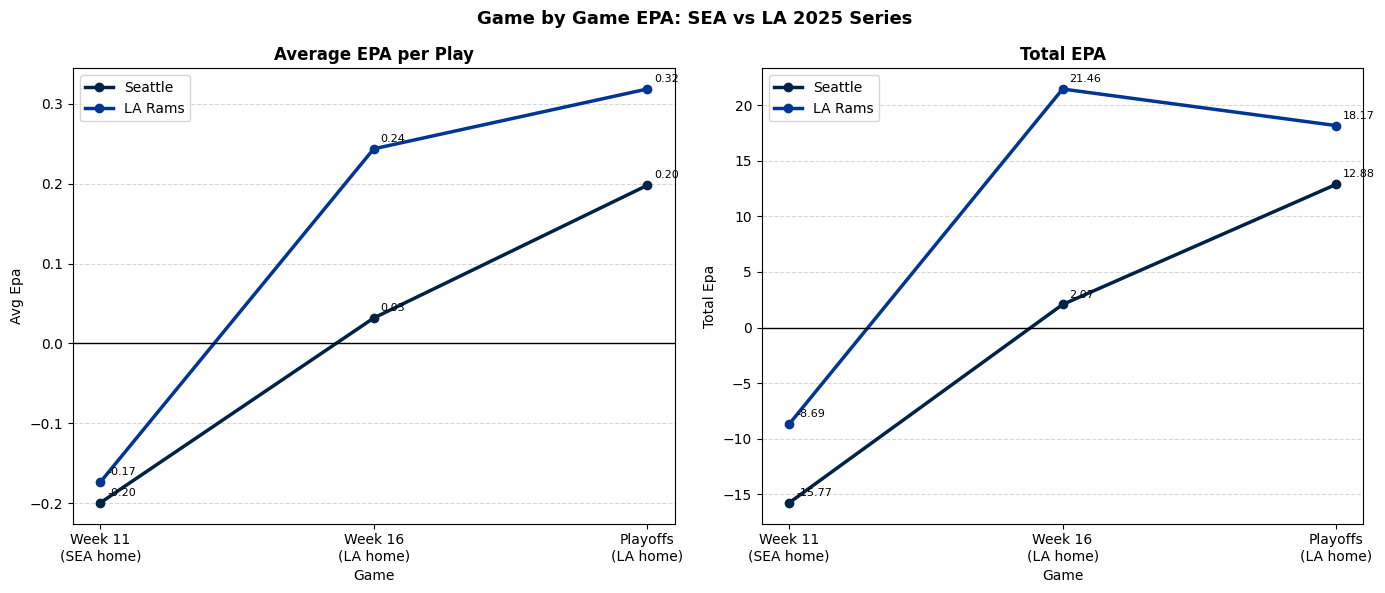

         game_label posteam  plays   avg_epa  total_epa
Week 11\n(SEA home)      LA     50 -0.173882  -8.694098
Week 11\n(SEA home)     SEA     79 -0.199655 -15.772758
 Week 16\n(LA home)      LA     88  0.243817  21.455902
 Week 16\n(LA home)     SEA     65  0.031875   2.071903
Playoffs\n(LA home)      LA     57  0.318726  18.167391
Playoffs\n(LA home)     SEA     65  0.198112  12.877283


In [8]:
# Game by game EPA breakdown
game_labels = {
    '2025_11_SEA_LA': 'Week 11\n(SEA home)',
    '2025_16_LA_SEA': 'Week 16\n(LA home)',
    '2025_21_LA_SEA': 'Playoffs\n(LA home)'
}

game_epa = sea_la.groupby(['game_id', 'posteam']).agg(
    plays=('epa', 'count'),
    avg_epa=('epa', 'mean'),
    total_epa=('epa', 'sum')
).reset_index()

game_epa['game_label'] = game_epa['game_id'].map(game_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, title in [
    (axes[0], 'avg_epa', 'Average EPA per Play'),
    (axes[1], 'total_epa', 'Total EPA')
]:
    for team, color, label in [('SEA', '#002244', 'Seattle'), ('LA', '#003594', 'LA Rams')]:
        data = game_epa[game_epa['posteam'] == team]
        ax.plot(data['game_label'], data[metric], marker='o', linewidth=2.5,
                color=color, label=label)
        for _, row in data.iterrows():
            ax.annotate(f"{row[metric]:.2f}",
                       xy=(row['game_label'], row[metric]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)

    ax.axhline(y=0, color='black', linewidth=1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Game')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Game by Game EPA: SEA vs LA 2025 Series', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "sea_la_game_by_game.png"), dpi=150, bbox_inches='tight')
plt.show()

print(game_epa[['game_label', 'posteam', 'plays', 'avg_epa', 'total_epa']].to_string(index=False))

![Game by Game EPA](../outputs/figures/sea_la_game_by_game.png)

The game by game trajectory tells a fascinating story about how this series evolved:

**Week 11 (Seattle home):**
- Both offenses were completely shut down — Seattle (-0.200 EPA) and LA (-0.174 EPA) both generated negative EPA
- Total EPA of -15.8 for Seattle and -8.7 for LA suggests a defensive battle where neither offense found any rhythm
- Seattle won this game despite negative offensive EPA, suggesting special teams or turnovers were decisive

**Week 16 (LA home):**
- A dramatic reversal — the Rams exploded to +0.244 EPA per play and +21.5 total EPA
- Seattle improved to +0.032 EPA but still well below the Rams
- The Rams clearly made significant adjustments from Week 11, finding the formation and personnel combinations that worked against Seattle's defense

**Playoffs (LA home):**
- Both offenses reached their peak efficiency of the series
- LA continued their dominance at +0.319 EPA — the highest single game performance in the series
- Seattle had their best game at +0.198 EPA, a significant improvement from Week 11
- Despite Seattle's improvement, the Rams were still more efficient — explaining the playoff outcome

**The trend line tells the story:** The Rams improved dramatically from Week 11 to the playoffs, going from -0.174 to +0.319 EPA. Seattle also improved but never matched the Rams' peak efficiency. The Rams' ability to adapt their formation and personnel usage across the series — leaning into 13 personnel, Under Center, and go/post routes — proved decisive.

---

### Summary
This case study confirms and enriches the league-wide findings from earlier notebooks:

1. **The Rams' heavy 13 personnel usage (51%) directly applied the league-wide finding** that 13 personnel is the most blitz-proof package and generates strong EPA against man coverage
2. **Seattle's reliance on 11 personnel (-0.026 EPA) despite negative results** illustrates the systemic inefficiency of defaulting to spread formations regardless of what the defense shows
3. **The Rams' 12 personnel generated +0.920 EPA** — the highest single personnel package performance in this series, consistent with 12 personnel's strong performance against zone coverages
4. **Post and go routes dominated for the Rams** — exactly what the league-wide route vs coverage matrix predicted against Seattle's zone-heavy defense
5. **The Rams improved from -0.174 to +0.319 EPA across the series** — a textbook example of in-season formation and personnel adjustment based on what the data shows works against a specific opponent